## Law Gender Bias - 2 OBJECTIVES

### Multi Task Learning

* **Dataset:** Law Gender Bias
* **Task :** Classification

* **Target 1:** Predicting bias in statements related to the Victim
* **Target 2:** Predicting bias in statements related to the Defendant

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import json
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer
from typing import Any
from collections.abc import Callable
from sklearn.model_selection import train_test_split

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

from scalarization import NLPScalarization

In [5]:
# Setting a seed for reproducibility
from machinemoo.utils.seed_config import set_np_torch_seed
set_np_torch_seed(42)

In [6]:
import pickle

In [7]:
PREFIX_SAVE_IMAGE = 'images/2_objs'

In [8]:
PREFIX_SAVE_RESULT = '2_objs'

## Dataset and Model

In [9]:
def prepare_datasets(json_path: str): 

    with open(json_path, 'r') as f:
        data = json.load(f)

    train_keys, test_keys = train_test_split(list(data.keys()), test_size=0.1, random_state=42)
    train_keys, val_keys = train_test_split(train_keys, test_size=0.2, random_state=42)

    train_data = {key: data[key] for key in train_keys}
    val_data= {key: data[key] for key in val_keys}
    test_data = {key: data[key] for key in test_keys}
    
    return train_data, val_data, test_data 

In [10]:
#train_data, val_data, test_data = prepare_datasets('../ap/files/annotate_filled.json')
train_data, val_data, test_data = prepare_datasets('../lesao/files/annotate_filled.json')   

In [11]:
# Use GPU if its available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


### Dataset Analysis

In [12]:
# Cell 3: Dataset class
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
MAX_LEN = 512
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir="transformers")

class MultiTaskDataset(Dataset):
    """
    Flexible dataset for multi-task classification from a JSON-like dict format.
    Supports multiple text chunks and multiple label fields.
    """

    def __init__(self,
                 data: dict,
                 tokenizer,
                 max_length: int = 512,
                 chunk_field: str = "vies_contexto",
                 label_extractors: dict[str, Callable[[dict[str, Any]], int]] = {},
                ) -> None:
        """
        Parameters:
        - data: loaded JSON-like dict
        - tokenizer: HuggingFace tokenizer
        - max_length: max token length
        - chunk_field: which text chunk to use (e.g., 'vies_contexto')
        - label_extractors: dictionary mapping task names to label extraction functions
        - data_type: optional, used for augmentation
        """
        self.tokenizer = tokenizer
        self.max_length = max_length

        self.texts = []
        self.labels = {task: [] for task in label_extractors}

        for item in data.values():
            for text in item.get(chunk_field, []):
                self.texts.append(text)
                for task_name, extractor_fn in label_extractors.items():
                    label = extractor_fn(item)
                    self.labels[task_name].append(label)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer.encode_plus(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            add_special_tokens=True
        )

        item = {
            'input_ids': torch.LongTensor(encoding['input_ids']),
            'attention_mask': torch.LongTensor(encoding['attention_mask'])
        }

        for task_name in self.labels:
            item[f'{task_name}'] = torch.tensor(self.labels[task_name][idx], dtype=torch.long)

        return item

In [13]:
def key_presence_extractor(key: str, subkey: str = "") -> Callable[[dict[str, Any]], int]:
    """
    Returns a function that checks if `key` (and optionally `subkey`) is present in the sample.
    Useful for binary presence labels.
    """
    def extractor(sample: dict[str, Any]) -> int:
        if subkey != "":
            val = sample.get("vies", [""])[0] if isinstance(sample.get("vies"), list) else sample.get("vies")
            res = bool(val)
            if res:
                result = subkey in sample.get(key, {})
            else: 
                result = 0
        else:
            val = sample.get(key, [""])[0] if isinstance(sample.get(key), list) else sample.get(key)
            result = bool(val)
        return int(result)
    return extractor

In [14]:
task_config = {
    "Victim": key_presence_extractor("vies_alvo", subkey="vitima"),
    "Defendant": key_presence_extractor("vies_alvo", subkey="reu"),
}

In [15]:
trainset = MultiTaskDataset(data=train_data, tokenizer=tokenizer, label_extractors=task_config)
train_dataloader = DataLoader(trainset, batch_size=64, shuffle=True)

valset = MultiTaskDataset(data=val_data, tokenizer=tokenizer, label_extractors=task_config)
valid_dataloader = DataLoader(valset, batch_size=64)

testset = MultiTaskDataset(data=test_data, tokenizer=tokenizer, label_extractors=task_config)
test_dataloader = DataLoader(testset, batch_size=64)

### Dataset Analysis

In [15]:
print(f"Train Set Size  : {len(train_data)}")
print(f"Val Set Size    : {len(val_data)}")
print(f"Test Set Size   : {len(test_data)}")
# next(iter(train_data.items()))

Train Set Size  : 115
Val Set Size    : 29
Test Set Size   : 16


In [16]:
from collections import Counter

# Count each label in the training set
victim_counts = Counter(trainset.labels["Victim"])
defendant_counts = Counter(trainset.labels["Defendant"])

total_examples = len(trainset)

print("=== Training Set Distribution ===\n")

# Victim
victim_total = victim_counts[0] + victim_counts[1]
victim_percent_biased = (victim_counts[1] / victim_total * 100) if victim_total > 0 else 0
print(f"Victim:        {victim_counts[1]} biased / {victim_total} total ({victim_percent_biased:.2f}%)")

# Defendant
defendant_total = defendant_counts[0] + defendant_counts[1]
defendant_percent_biased = (defendant_counts[1] / defendant_total * 100) if defendant_total > 0 else 0
print(f"Defendant:     {defendant_counts[1]} biased / {defendant_total} total ({defendant_percent_biased:.2f}%)")

print(f"\nTotal training examples: {total_examples}")


=== Training Set Distribution ===

Victim:        27 biased / 290 total (9.31%)
Defendant:     39 biased / 290 total (13.45%)

Total training examples: 290


In [17]:
def analyze_bias_distribution(dataset, name="dataset") -> None:
    """
    Analyzes bias label distribution for a given dataset and prints a clear summary.

    Args:
        dataset: The dataset (e.g., trainset) that has a .labels dict.
        name: A string to identify the dataset in the output.
    """
    print(f"\nBias distribution in {name} (total examples = {len(dataset)}):\n")
    
    for label_name, values in dataset.labels.items():
        counts = Counter(values)
        total_with_bias = counts.get(1, 0)
        total_without_bias = counts.get(0, 0)
        total = total_with_bias + total_without_bias
        percent_biased = (total_with_bias / total * 100) if total > 0 else 0
        percent_unbiased = (total_without_bias / total * 100) if total > 0 else 0
        
        print(f"{label_name.capitalize()}:")
        print(f"    Without bias (0): {total_without_bias:5}  ({percent_unbiased:6.2f}%)")
        print(f"    With bias    (1): {total_with_bias:5}  ({percent_biased:6.2f}%)\n")


# Example usage
analyze_bias_distribution(trainset, "Train Set")


# Counting specific types of biases in the dataset
bias_types = ["vitima", "reu", "test", "mae", "abs_cri", "abs_mul", "mul", "abs_reu", "soc"]
bias_count = {b: 0 for b in bias_types}
total_examples = 0

for key, example in train_data.items():  # or `for example in dataset` if it's a list
    for b in bias_types:
        if b in example.get("vies_alvo", []):
            bias_count[b] += 1
    total_examples += 1

print("Specific bias counts in train set:")
for b in bias_types:
    count = bias_count[b]
    percent = (count / total_examples * 100) if total_examples > 0 else 0
    print(f"  {b:10}: {count:5} ({percent:6.2f}%)")
    
print(f"\nTotal examples processed: {total_examples}")



Bias distribution in Train Set (total examples = 290):

Victim:
    Without bias (0):   263  ( 90.69%)
    With bias    (1):    27  (  9.31%)

Defendant:
    Without bias (0):   251  ( 86.55%)
    With bias    (1):    39  ( 13.45%)

Specific bias counts in train set:
  vitima    :     5 (  4.35%)
  reu       :     8 (  6.96%)
  test      :     1 (  0.87%)
  mae       :     0 (  0.00%)
  abs_cri   :     0 (  0.00%)
  abs_mul   :    10 (  8.70%)
  mul       :     0 (  0.00%)
  abs_reu   :     1 (  0.87%)
  soc       :     3 (  2.61%)

Total examples processed: 115


In [18]:
from collections import Counter
import matplotlib.pyplot as plt

def summarize_labels(dataset, name="dataset") -> None:
    """
    Summarizes label distributions in the dataset.
    
    Args:
        dataset: The dataset object with a `.labels` dict.
        name: Name of the dataset (for display purposes).
    """
    print(f"\n📊 Label distribution in {name} (total examples: {len(dataset)}):\n")
    
    for label_name, values in dataset.labels.items():
        counts = Counter(values)
        total = counts.get(0, 0) + counts.get(1, 0)
        percent_0 = counts.get(0, 0) / total * 100 if total > 0 else 0
        percent_1 = counts.get(1, 0) / total * 100 if total > 0 else 0
        
        print(f"📝 {label_name.capitalize():<15}")
        print(f"    0 (no bias) : {counts.get(0,0):5} ({percent_0:6.2f}%)")
        print(f"    1 (with bias): {counts.get(1,0):5} ({percent_1:6.2f}%)")
        print("-" * 40)


In [19]:
def count_specific_biases(dataset_items, bias_types):
    """
    Counts occurrences of specific bias types in dataset examples.
    
    Args:
        dataset_items: Iterable of dataset examples (dicts).
        bias_types: List of bias names to count.
    """
    bias_count = {b: 0 for b in bias_types}
    total_examples = 0

    for example in dataset_items:
        for b in bias_types:
            if b in example.get("vies_alvo", []):
                bias_count[b] += 1
        total_examples += 1

    print("\nSpecific bias counts:")
    print(f"{'Bias type':<12} {'Count':>6} {'% of total':>12}")
    print("-" * 32)
    for b in bias_types:
        count = bias_count[b]
        percent = (count / total_examples * 100) if total_examples > 0 else 0
        print(f"{b:<12} {count:6} {percent:12.2f}%")
    print(f"\nTotal examples processed: {total_examples}")


In [20]:
def plot_bias_distribution(dataset, label_name="Victim"):
    counts = Counter(dataset.labels[label_name])
    plt.figure(figsize=(5,4))
    plt.bar([0,1], [counts.get(0,0), counts.get(1,0)], color=['#4CAF50','#F44336'])
    plt.xticks([0,1], ['No bias','With bias'])
    plt.ylabel('Number of examples')
    plt.title(f'{label_name.capitalize()} bias distribution')
    plt.show()


## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [16]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 500,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
objectives_names = list(task_config.keys())

# Control optimization output (Default is False):
#   verbose=True -> show optimization progress
#   debug=True   -> show detailed debug information
verbose = False
debug = False

def machine_optimize(method, lb_estimate=0.01):
    w_scalar = NLPScalarization(
        train_dataloader = train_dataloader, 
        device = device, 
        task_names = objectives_names,
        model_name = MODEL_NAME, 
        lower_bound_estimate=lb_estimate
    )
    moopt = moo(w_scalar, verbose=verbose, debug=debug).mo_optimization(method, **opt_params)
    objs = get_objectives(moopt)
    if method == 'mola':
        hypervolume_values = moopt.get_hypervolumes()
    else:
        hypervolume_values = compute_hypervolume_progress(objs)
    if lb_estimate == 'lipschitz':
        method = f'{method}_grad'
    results[method] = {
                    "moopt": moopt,
                    "objectives": objs,
                    "models": get_models(moopt),
                    "hypervolume": hypervolume_values
                }
    
def plot_frontier(method, color="#d73027"):
    title="Loss Trade-offs in Multi-Group Hate Speech Detection"
    plot_pareto(methods={method: results[method]['objectives']},
                labels=objectives_names, 
                title=title,
                color=color,
                fontsize=23,
                figsize=(10,7),
                save_path=f'{PREFIX_SAVE_IMAGE}_{method}.pdf'
                )

### MOLA

In [22]:
method = 'mola'
machine_optimize(method=method)

/home/lineccsa/mestrado/machinemoo/machinemoo/analysis/visualization.py:234: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=30, loc="upper right")


<Figure size 1000x700 with 0 Axes>

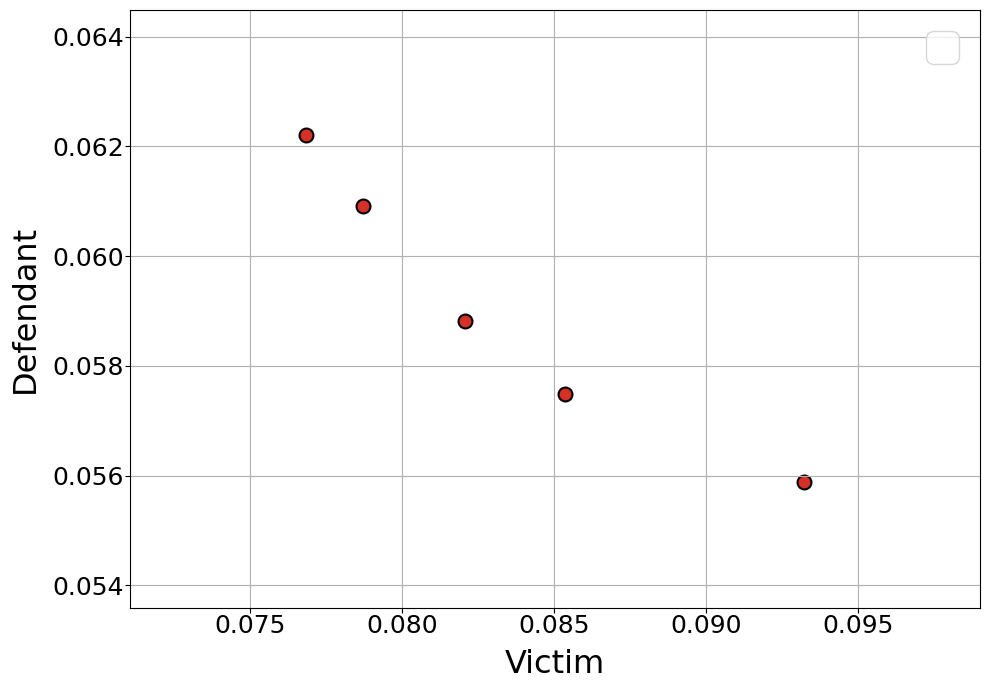

In [17]:
plot_frontier('mola', color='#d73027')

In [24]:
# save results
with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "wb") as f:
    pickle.dump(results, f)


### MOLA with gradient

In [25]:
method = 'mola'
machine_optimize(method=method, lb_estimate='lipschitz')

/home/lineccsa/mestrado/machinemoo/machinemoo/analysis/visualization.py:234: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=30, loc="upper right")


<Figure size 1000x700 with 0 Axes>

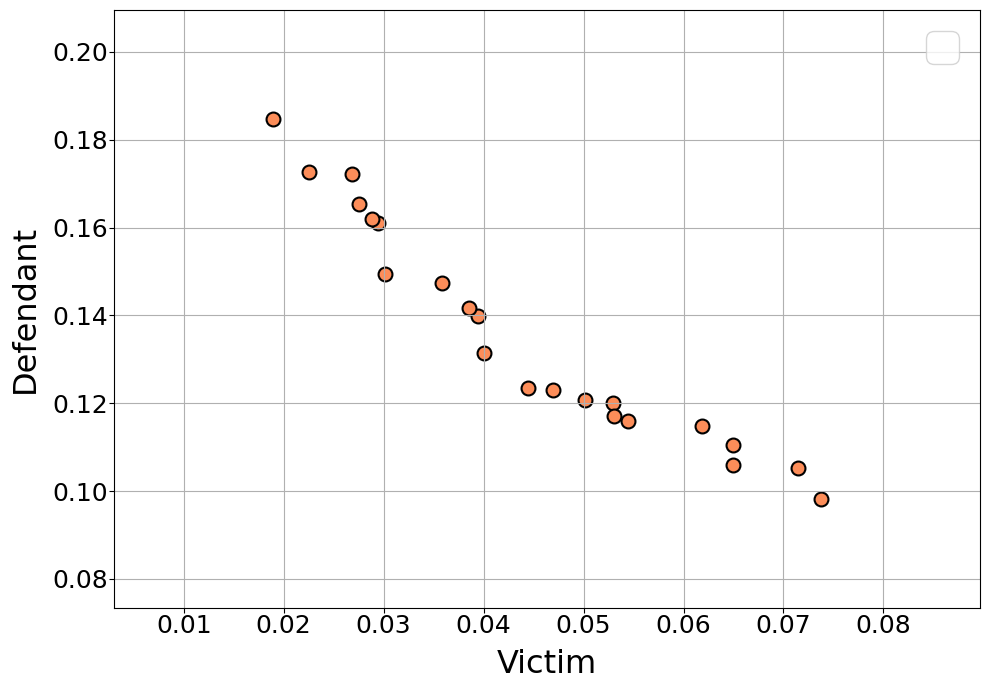

In [18]:
plot_frontier(f'mola_grad', color='#fc8d59')

In [27]:
# save results
with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "wb") as f:
    pickle.dump(results, f)

### Random Weights

In [28]:
method = 'random_weights'
machine_optimize(method=method)

### Non-dominated Solutions Analysis

In [18]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
rw_solutions = results['random_weights']['objectives']
nd_indices = NonDominatedSorting().do(rw_solutions, only_non_dominated_front=True)
rw_non_dominated_solutions = rw_solutions[nd_indices]

print(f'Number of non-dominated solutions with MOLA          : {len(results['mola']['objectives'])}')
print(f'Number of non-dominated solutions with MOLA GRAD     : {len(results['mola_grad']['objectives'])}')
print(f'Number of non-dominated solutions with RANDOM WEIGHT : {len(rw_non_dominated_solutions)}')

Number of non-dominated solutions with MOLA          : 5
Number of non-dominated solutions with MOLA GRAD     : 22
Number of non-dominated solutions with RANDOM WEIGHT : 4


## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

<string>:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<Figure size 3000x700 with 0 Axes>

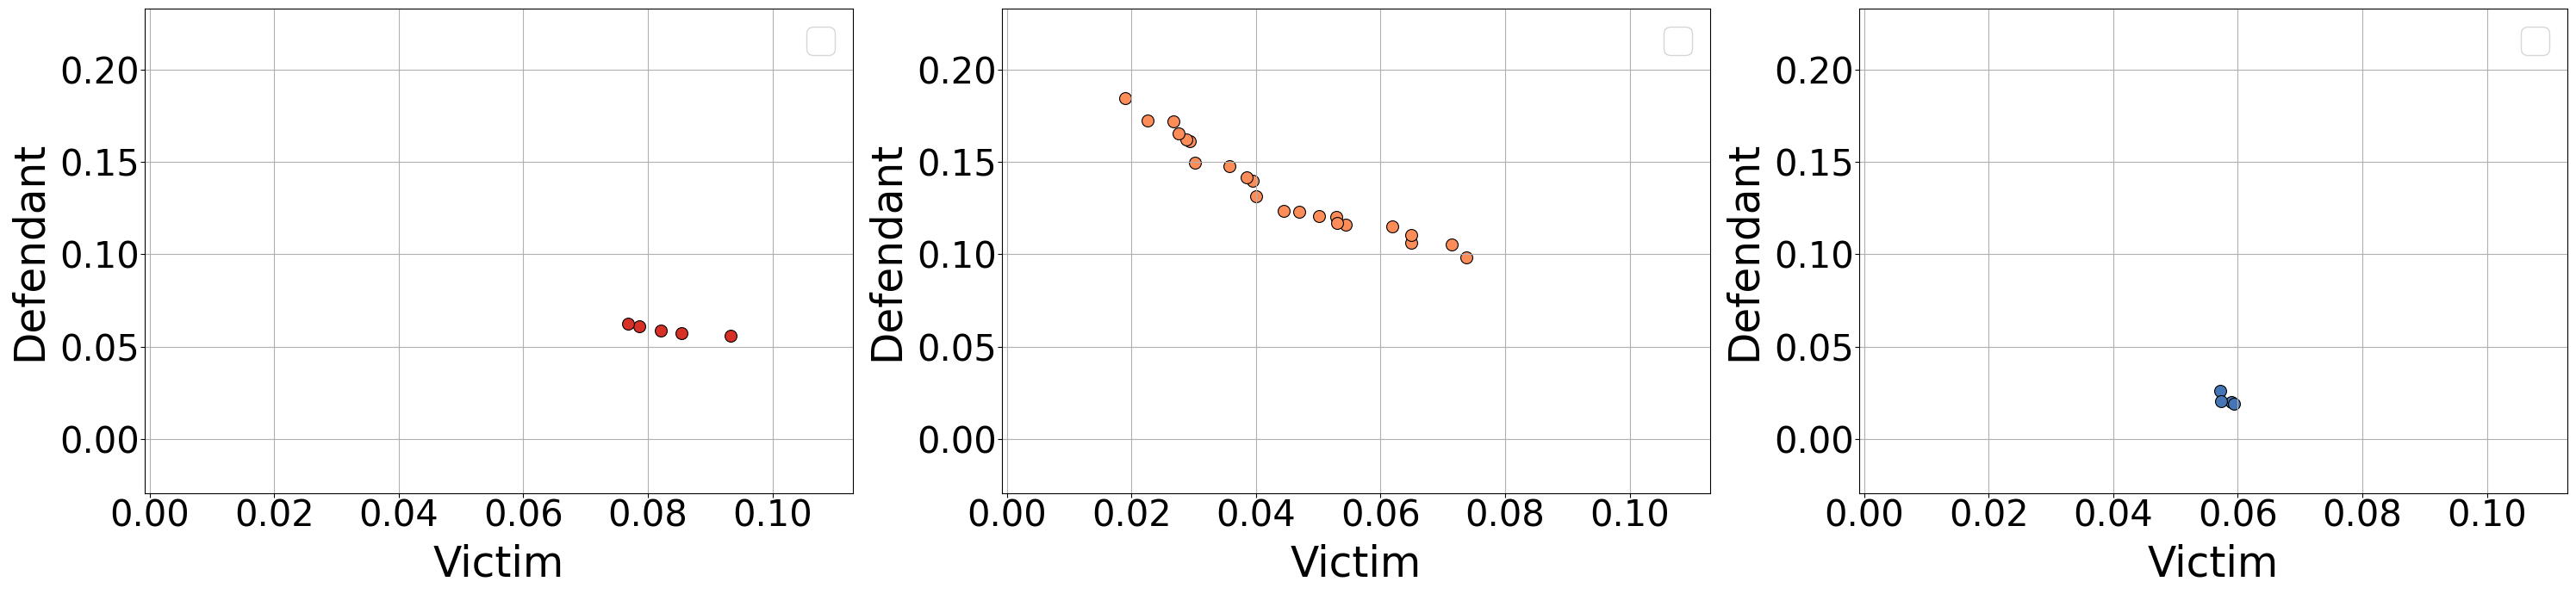

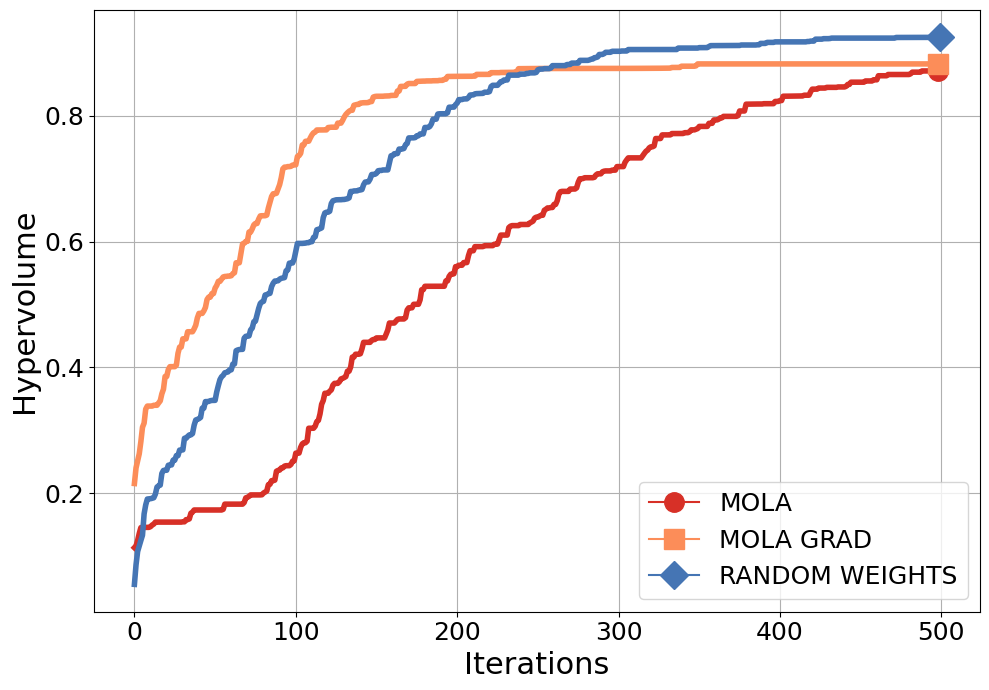

In [19]:
pareto_dict = {
        method: res['objectives']
        for method, res in results.items()
        if 'objectives' in res
    }

pareto_dict['random_weights'] = rw_non_dominated_solutions

hypervolumes_dict = {
        method: res['hypervolume']
        for method, res in results.items()
        if 'hypervolume' in res
    }

plot_pareto(methods=pareto_dict,
            labels=objectives_names, 
            #title='Comparative Pareto Frontiers Across MOO Methods',
            #subset=equal.objs,
            fontsize=35,
            figsize=(10,7),
            save_path=f'{PREFIX_SAVE_IMAGE}_methods.pdf'
            )

plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path=f'{PREFIX_SAVE_IMAGE}_hypervolume.pdf')

In [ ]:
# save results
#with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "wb") as f:
#    pickle.dump(results, f)

In [ ]:
# get saved results
#with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "rb") as f:
#    results = pickle.load(f)

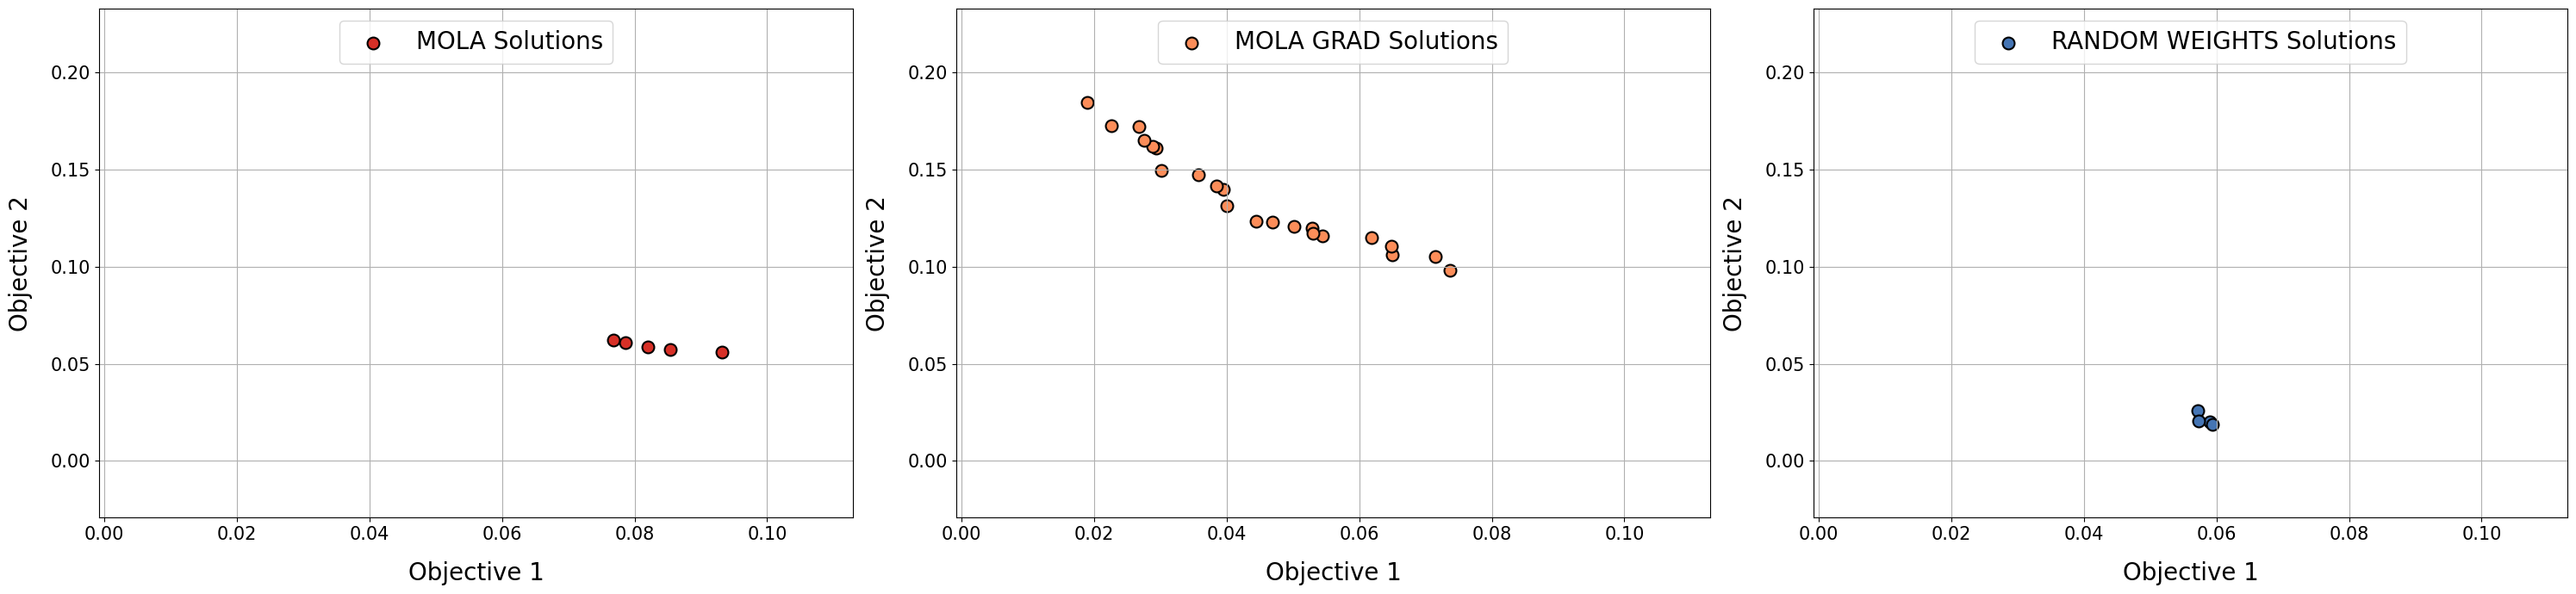

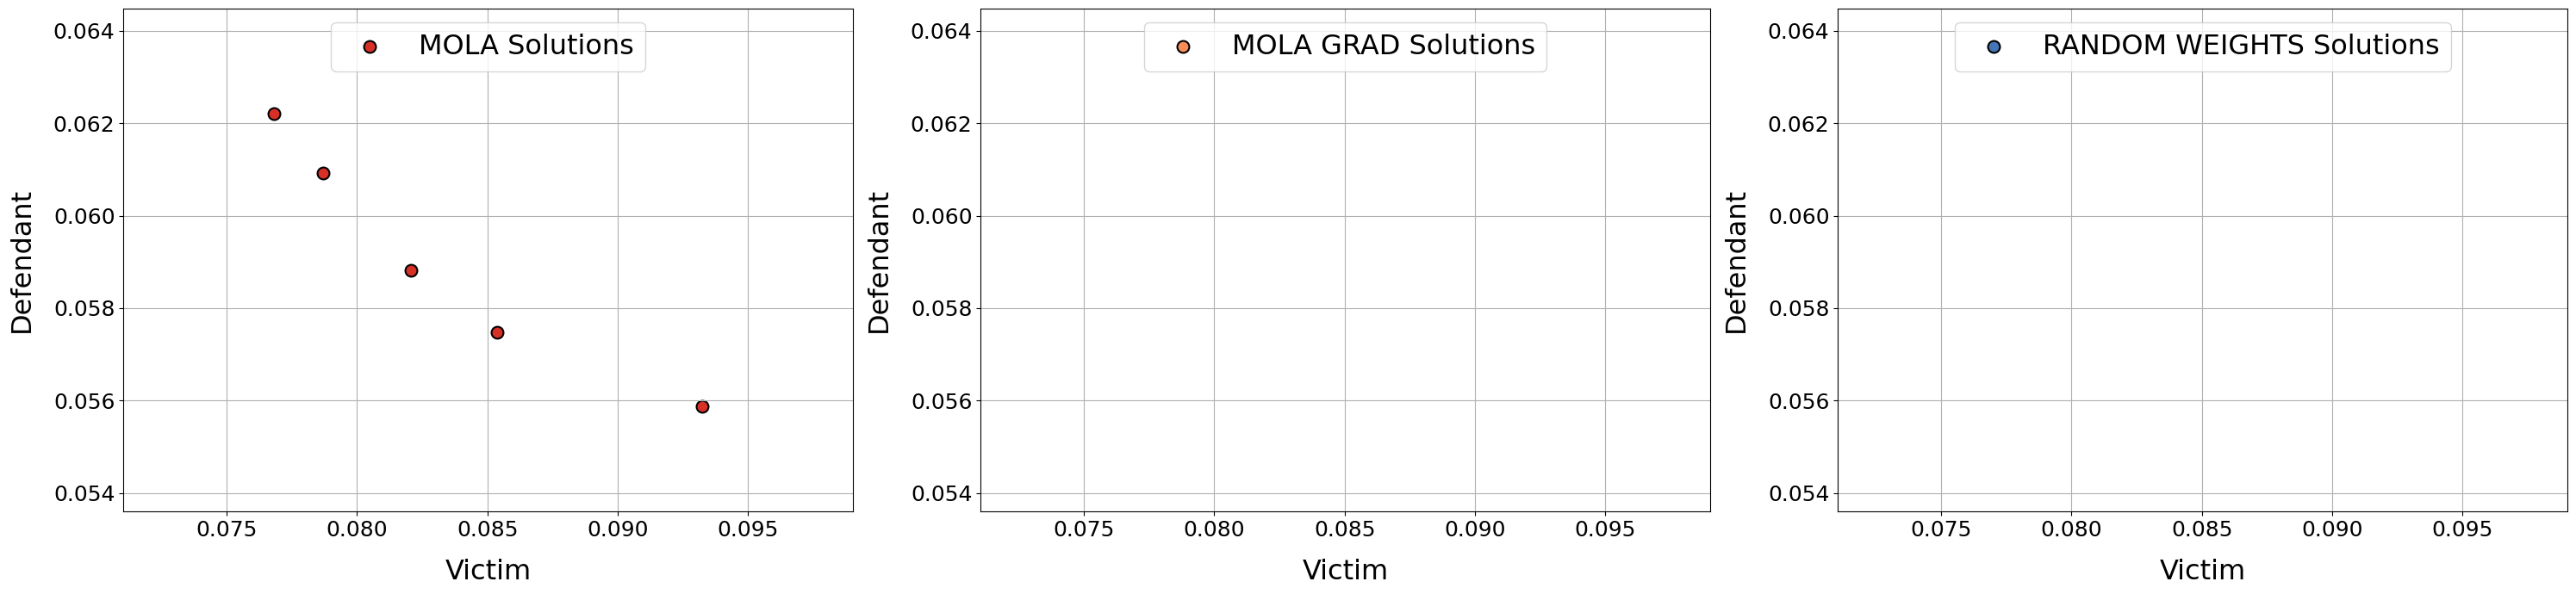

In [33]:
from machinemoo.analysis.visualization import plot_pareto_set_limit
plot_pareto_set_limit(methods=pareto_dict, axis_mode="global")
plot_pareto_set_limit(methods=pareto_dict, 
                      axis_mode="first", 
                      title="",
                      labels=objectives_names, 
                      fontsize=23,
                      figsize=(10,7),
                      save_path=f'{PREFIX_SAVE_IMAGE}_limit.pdf')